# PCA

## Off
- tìm một hệ cơ sở mới trong không gian trực chuẩn 
- Du lie xap si la du lieu trong khong gian 2 trieu 

## Vi du 1. 
- Trong ví dụ này, chúng ta sử dụng PCA để phân tích và giảm số chiều của bộ dữ liệu hoa IRIS
(xem lại bài thực hành phần Naïve Bayes). Dữ liệu gồm có 150 mẫu hoa phân đều trong 03 loại (class), mỗi
mẫu có 04 chiều. Dữ liệu có thể lấy từ tệp Iris.csv đính kèm hoặc link:
https://drive.google.com/file/d/1rb2ZQCllKCIP7Z1SZe9_T3XMKlUUfeB3/view . Thông tin thêm về dữ
liệu có thể tham khảo lại trong bài hướng dẫn thực hành các phần Naïve Bayes hoặc SoftMax, hoặc trong
link https://archive.ics.uci.edu/ml/datasets/iris. Do kích thước dữ liệu khá nhỏ nên trong ví dụ này chúng ta
sẽ không sử dụng công cụ PCA của sklearn mà xây dựng từ các công cụ đại số tuyến tính của numpy. Ngoài
ra chúng ta sẽ sử dụng công cụ PANDAS để đọc tệp CSV và một số công cụ vẽ để hiển thị kết quả
(matplotlib.pyplot và seaborn).


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa
       sepal.length  sepal.width  petal.length  petal.width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


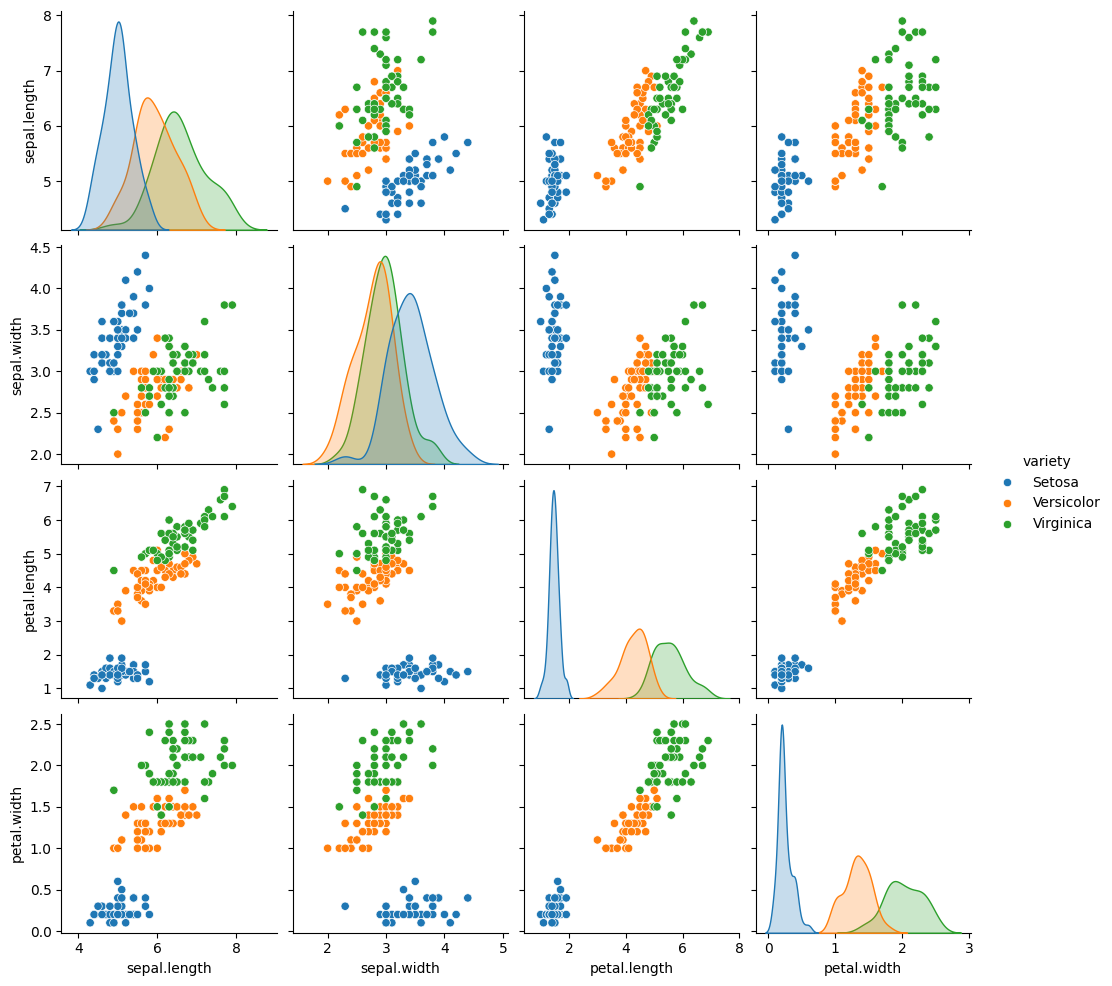

In [4]:
df = pd.read_csv("iris.csv")
print(df.head(5))
print(df.describe())

sns.pairplot(df, hue = 'variety')

Text(0.5, 1.0, 'correlation matrix')

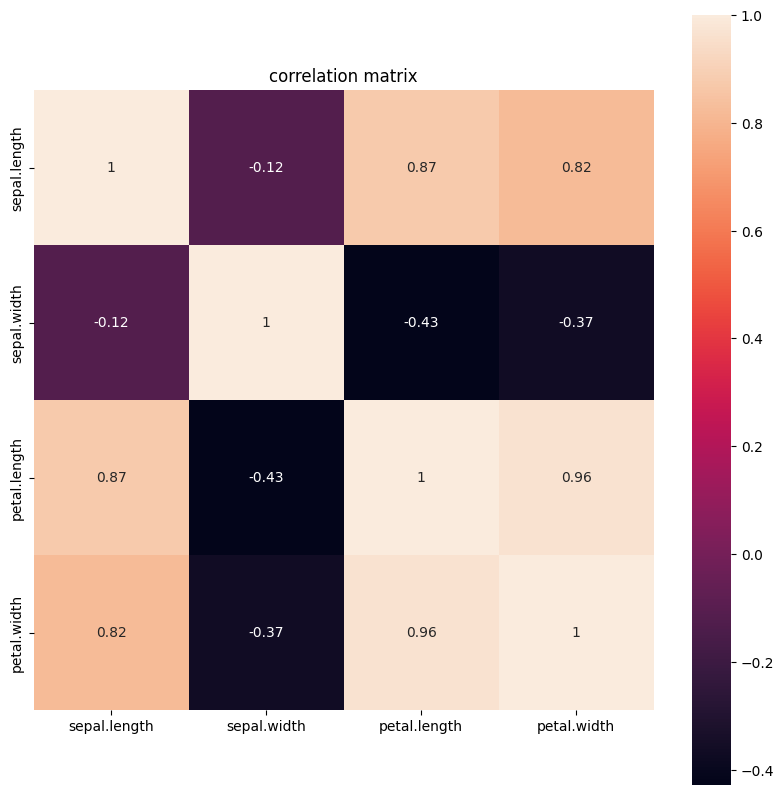

In [20]:
#Chuẩn hóa và tính ma trận hiệp phương sai của dữ liệu:
species = df["variety"].tolist()
X = df.drop("variety", axis=1)

# Standardize the data
X = (X - X.mean()) / X.std(ddof = 0)

# Tinh correlation matrix 
X_corr = (1/150) * X.T.dot(X)

plt.figure(figsize=(10,10))
sns.heatmap(X_corr, vmax = 1, square = True, annot = True)
plt.title("correlation matrix")

- Trong đoạn chương trình dưới đây, chúng ta tính hệ riêng của ma trận hiệp phương sai (X_corr) bằng
cả 2 công cụ của thư viện Numpy.Linalg là SVD (khai triển kỳ dị) và Eig (Khai triển hệ giá trị-vector
riêng), sau đó in ra kết quả để so sánh

In [22]:
u,s,v = np.linalg.svd(X_corr)
eig_values, eig_vectors = s, u
eig_values, eig_vectors

np.linalg.eig(X_corr)

EigResult(eigenvalues=array([2.91849782, 0.91403047, 0.14675688, 0.02071484]), eigenvectors=array([[ 0.52106591, -0.37741762, -0.71956635,  0.26128628],
       [-0.26934744, -0.92329566,  0.24438178, -0.12350962],
       [ 0.5804131 , -0.02449161,  0.14212637, -0.80144925],
       [ 0.56485654, -0.06694199,  0.63427274,  0.52359713]]))

- Đoạn chương trình dưới đây hiển thị mức độ “quan trọng” của các trường dữ liệu (gồm 04 trường theo
thứ tự như trong mô tả dữ liệu

Text(0.5, 0, 'Dimensions')

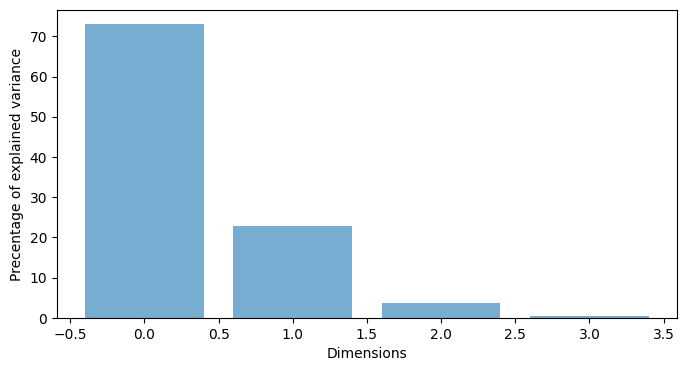

In [23]:
explained_variance = (eig_values / np.sum(eig_values)) * 100
plt.figure(figsize=(8,4))
plt.bar(range(4), explained_variance, alpha = 0.6)
plt.ylabel("Precentage of explained variance")
plt.xlabel("Dimensions")


- Đoạn chương trình chứa thủ tục chiếu dữ liệu (X) xuống không gian con 02 chiều ứng với 2 giá trị riêng
lớn nhất (tức là trị riêng [0] và trị riêng [1])

In [24]:
pc1 = X.dot(eig_vectors[:, 0])
pc2 = X.dot(eig_vectors[:, 1])

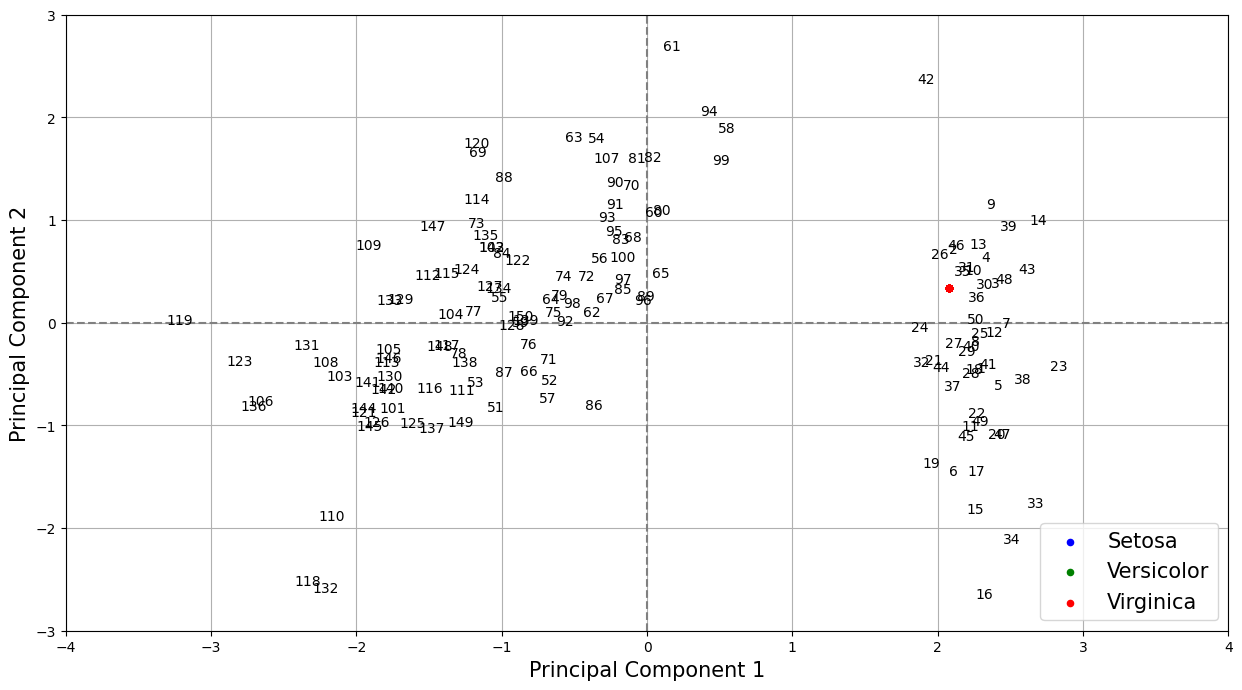

In [25]:
# Ve du lieu khong gian 2 chieu moi thanh lap de quan sat

def plot_scatter(pc1, pc2):
    fig, ax = plt.subplots(figsize =(15, 8))
    
    species_unique = list(set(species))
    species_colors = ["r", "b", "g"]
    
    for i, spec in enumerate(species):
        plt.scatter(pc1[1], pc2[2], label = spec
                    , s = 20, c = species_colors[species_unique.index(spec)])
        ax.annotate(str(i + 1), (pc1[i], pc2[i]))
        
    from collections import OrderedDict
    handles, labels = plt.gca().get_legend_handles_labels() 
    by_label = OrderedDict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), prop={'size': 15}, loc=4)
    ax.set_xlabel('Principal Component 1', fontsize = 15)
    ax.set_ylabel('Principal Component 2', fontsize = 15)
    ax.axhline(y=0, color="grey", linestyle="--")
    ax.axvline(x=0, color="grey", linestyle="--")
    plt.grid()
    plt.axis([-4, 4, -3, 3])
    plt.show()

plot_scatter(pc1, pc2)

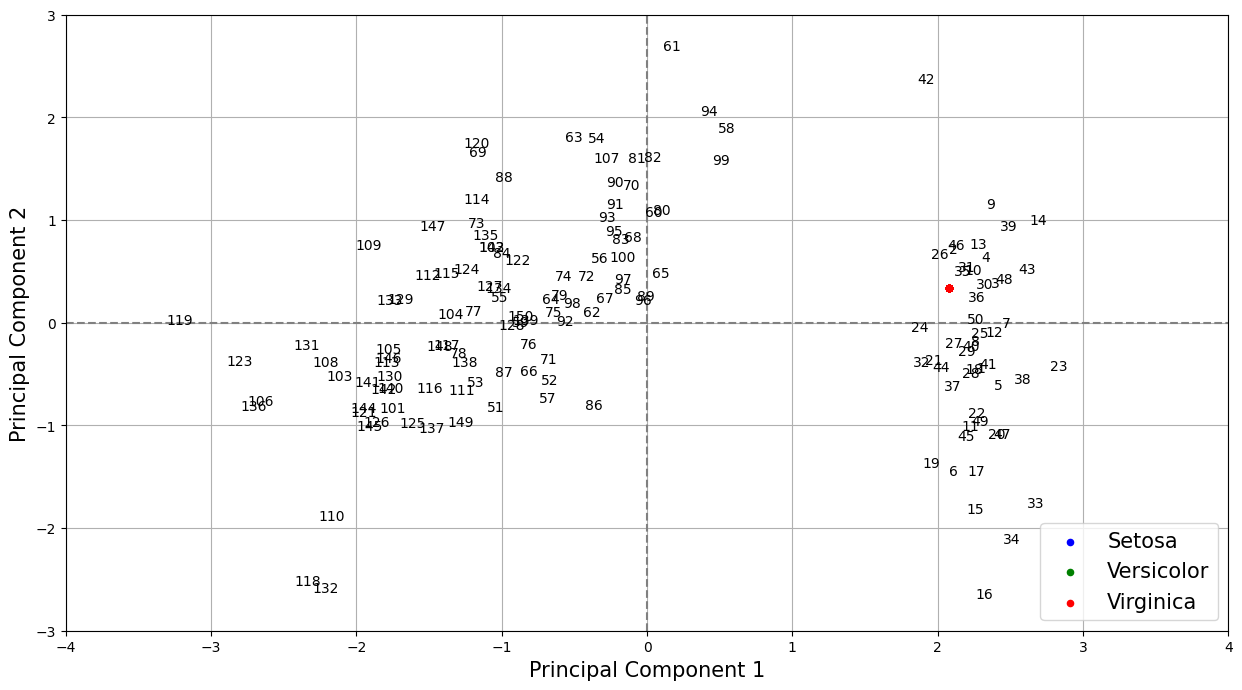

In [28]:
X = df.drop("variety", axis = 1)
X = StandardScaler().fit_transform(X)
pca = PCA()
result = pca.fit_transform(X)
# Remember what we said about the sign of eigen vectors that might change ?
pc1 = - result[:,0]
pc2 = - result[:,1]
plot_scatter(pc1, pc2)

### 1) Sử dụng đoạn code chọn số chiều chính trong ví dụ trên, đưa tập dữ liệu đã đọc về còn 2 chiều,sau đó hiển thị lên màn hình để xem quan hệ giữa các lớp dữ liệu.


### 2) Với đoạn chương trình đọc dữ liệu đã có, hãy chạy lại ví dụ này với các thư viện của gói linear_model, lớp LogisticRegression và so sánh kết quả, chia Train:Test = 4:1 (theo từng loại hoa để tránh phân bố các loại hoa trong tập train và tập test mất cân bằng), tương ứng với 02 trường hợp:
- a. Chạy với dữ liệu nguyên bản, lưu lại độ chính xác, ma trận nhầm lẫn trong trường hợp
này;
- b. Chạy với dữ liệu giảm chiều, hãy xử lý theo 02 quy trình dưới đây:
- i. Chia dữ liệu thành Train – Test, sau đó thực hiện giảm chiều một cách phù hợp
và thực hiện bài toán phân loại. Lưu lại các kết quả.
- ii. Thực hiện giảm chiều trên toàn bộ dữ liệu, sau đó chia thành dữ liệu train:test và
thực hiện bài toán phân loại.
Hãy so sánh kết quả trong 2 trường hợp i) và ii) để tìm ra quy trình phù hợp khi xử lý
giảm chiều dữ liệu để phục vụ bài toán phân loại (tương tự với hồi quy). Hãy giải thích.
Sau đó so sánh kết quả trong trường hợp dữ liệu nguyên bản và dữ liệu giảm chiều.